In [146]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report
from scipy.stats import randint
from sklearn.model_selection import train_test_split

In [147]:
# Carregar dataset ULTRA-OTIMIZADO (sem jaccard, sem clustering, apenas features importantes)
df = pd.read_csv('../data/datasetTreino_node2vec.csv')

X = df.drop(columns=['y', 'u', 'v'])  # Remover também u, v
y = df['y']

print(f"Dataset OTIMIZADO carregado: {df.shape}")
print(f"Features: {X.shape[1]} (apenas as mais importantes)")
print(f"Balanceamento: {y.value_counts().to_dict()}")
print(f"Features: {list(X.columns)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

Dataset OTIMIZADO carregado: (200000, 42)
Features: 39 (apenas as mais importantes)
Balanceamento: {0: 181416, 1: 18584}
Features: ['u_deg', 'v_deg', 'u_pagerank', 'v_pagerank', 'deg_diff', 'pagerank_diff', 'deg_ratio', 'pagerank_ratio', 'aa_score', 'u_community', 'v_community', 'same_community', 'u_comm_size', 'v_comm_size', 'comm_size_diff', 'emb_dot_product', 'emb_cosine_sim', 'emb_euclidean_sim', 'emb_mean_u', 'emb_mean_v', 'emb_std_u', 'emb_std_v', 'emb_mean_diff', 'emb_std_diff', 'emb_u_dim_0', 'emb_v_dim_0', 'emb_diff_dim_0', 'emb_u_dim_1', 'emb_v_dim_1', 'emb_diff_dim_1', 'emb_u_dim_2', 'emb_v_dim_2', 'emb_diff_dim_2', 'emb_u_dim_3', 'emb_v_dim_3', 'emb_diff_dim_3', 'emb_u_dim_4', 'emb_v_dim_4', 'emb_diff_dim_4']


In [148]:
# NOVA VERSÃO: Carregar dataset com Node2Vec embeddings
df_node2vec = pd.read_csv('../data/datasetTreino_node2vec.csv')

X_node2vec = df_node2vec.drop(columns=['y', 'u', 'v'])
y_node2vec = df_node2vec['y']

print(f"Dataset Node2Vec carregado: {df_node2vec.shape}")
print(f"Features: {X_node2vec.shape[1]} (15 clássicas + Node2Vec)")
print(f"Balanceamento: {y_node2vec.value_counts().to_dict()}")
print("Features clássicas + Node2Vec:")
for i, col in enumerate(X_node2vec.columns):
    if i < 15:
        print(f"  {col} (clássica)")
    else:
        print(f"  {col} (Node2Vec)")

X_train_n2v, X_test_n2v, y_train_n2v, y_test_n2v = train_test_split(
    X_node2vec, y_node2vec, test_size=0.2, stratify=y_node2vec, random_state=42)

Dataset Node2Vec carregado: (200000, 42)
Features: 39 (15 clássicas + Node2Vec)
Balanceamento: {0: 181416, 1: 18584}
Features clássicas + Node2Vec:
  u_deg (clássica)
  v_deg (clássica)
  u_pagerank (clássica)
  v_pagerank (clássica)
  deg_diff (clássica)
  pagerank_diff (clássica)
  deg_ratio (clássica)
  pagerank_ratio (clássica)
  aa_score (clássica)
  u_community (clássica)
  v_community (clássica)
  same_community (clássica)
  u_comm_size (clássica)
  v_comm_size (clássica)
  comm_size_diff (clássica)
  emb_dot_product (Node2Vec)
  emb_cosine_sim (Node2Vec)
  emb_euclidean_sim (Node2Vec)
  emb_mean_u (Node2Vec)
  emb_mean_v (Node2Vec)
  emb_std_u (Node2Vec)
  emb_std_v (Node2Vec)
  emb_mean_diff (Node2Vec)
  emb_std_diff (Node2Vec)
  emb_u_dim_0 (Node2Vec)
  emb_v_dim_0 (Node2Vec)
  emb_diff_dim_0 (Node2Vec)
  emb_u_dim_1 (Node2Vec)
  emb_v_dim_1 (Node2Vec)
  emb_diff_dim_1 (Node2Vec)
  emb_u_dim_2 (Node2Vec)
  emb_v_dim_2 (Node2Vec)
  emb_diff_dim_2 (Node2Vec)
  emb_u_dim_3 (Node

In [149]:
# Treinar Random Forest com features Node2Vec
print("Treinando Random Forest com features Node2Vec...")
start_time = time.time()

rf_node2vec = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    criterion='gini',
    n_jobs=-1,
    random_state=42,
    class_weight='balanced_subsample'
)

rf_node2vec.fit(X_train_n2v, y_train_n2v)

# Avaliar modelo
y_pred_n2v = rf_node2vec.predict(X_test_n2v)
f1_n2v = f1_score(y_test_n2v, y_pred_n2v, average='weighted')

end_time = time.time()
training_time = end_time - start_time

print(f"Tempo de treinamento: {training_time:.2f} segundos")
print(f"F1-score Node2Vec: {f1_n2v:.4f}")
print("\nRelatório detalhado:")
print(classification_report(y_test_n2v, y_pred_n2v))

Treinando Random Forest com features Node2Vec...
Tempo de treinamento: 36.02 segundos
F1-score Node2Vec: 0.9922

Relatório detalhado:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     36283
           1       0.93      0.98      0.96      3717

    accuracy                           0.99     40000
   macro avg       0.97      0.99      0.98     40000
weighted avg       0.99      0.99      0.99     40000

Tempo de treinamento: 36.02 segundos
F1-score Node2Vec: 0.9922

Relatório detalhado:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     36283
           1       0.93      0.98      0.96      3717

    accuracy                           0.99     40000
   macro avg       0.97      0.99      0.98     40000
weighted avg       0.99      0.99      0.99     40000



In [150]:
# Análise de importância das features Node2Vec
feature_importances_n2v = pd.DataFrame({
    'feature': X_node2vec.columns,
    'importance': rf_node2vec.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 features mais importantes (Node2Vec):")
print(feature_importances_n2v.head(20))

print("\n" + "="*50)
print("COMPARAÇÃO DE TIPOS DE FEATURES:")

# Categorizar features
classical_features = []
node2vec_features = []

for _, row in feature_importances_n2v.iterrows():
    if row['feature'].startswith('emb_'):
        node2vec_features.append((row['feature'], row['importance']))
    else:
        classical_features.append((row['feature'], row['importance']))

print(f"\nTop features CLÁSSICAS:")
for feat, imp in classical_features[:10]:
    print(f"  {feat}: {imp:.4f}")

print(f"\nTop features NODE2VEC:")
for feat, imp in node2vec_features[:10]:
    print(f"  {feat}: {imp:.4f}")

# Estatísticas agregadas
classical_importance = sum([imp for _, imp in classical_features])
node2vec_importance = sum([imp for _, imp in node2vec_features])

print(f"\nIMPORTÂNCIA TOTAL:")
print(f"Features clássicas: {classical_importance:.4f} ({classical_importance*100:.1f}%)")
print(f"Features Node2Vec: {node2vec_importance:.4f} ({node2vec_importance*100:.1f}%)")

Top 20 features mais importantes (Node2Vec):
              feature  importance
17  emb_euclidean_sim    0.287880
16     emb_cosine_sim    0.225954
15    emb_dot_product    0.091455
8            aa_score    0.053855
0               u_deg    0.051255
1               v_deg    0.050004
3          v_pagerank    0.037374
2          u_pagerank    0.034566
11     same_community    0.028770
14     comm_size_diff    0.021480
23       emb_std_diff    0.016335
6           deg_ratio    0.016097
5       pagerank_diff    0.015131
4            deg_diff    0.009138
20          emb_std_u    0.008023
21          emb_std_v    0.006277
22      emb_mean_diff    0.004446
13        v_comm_size    0.004390
29     emb_diff_dim_1    0.003925
12        u_comm_size    0.003907

COMPARAÇÃO DE TIPOS DE FEATURES:

Top features CLÁSSICAS:
  aa_score: 0.0539
  u_deg: 0.0513
  v_deg: 0.0500
  v_pagerank: 0.0374
  u_pagerank: 0.0346
  same_community: 0.0288
  comm_size_diff: 0.0215
  deg_ratio: 0.0161
  pagerank_diff: 0.

In [151]:
# Gerar predições finais com Node2Vec
print("Gerando predições finais com Node2Vec...")

# Carregar dataset de teste Node2Vec
df_test_n2v = pd.read_csv('../data/datasetTeste_node2vec.csv')
X_test_final_n2v = df_test_n2v.drop(columns=['u', 'v'])

# Fazer predições
predictions_n2v = rf_node2vec.predict_proba(X_test_final_n2v)[:, 1]

# Carregar IDs originais para criar submission
df_original = pd.read_csv('../data/edgesToEvaluate.csv')
submission_n2v = pd.DataFrame({
    'linkID': df_original['linkID'],
    'prediction': predictions_n2v
})

# Salvar submission Node2Vec
submission_n2v.to_csv('submission_node2vec.csv', index=False)

print(f"Submission Node2Vec salva: submission_node2vec.csv")
print(f"Shape: {submission_n2v.shape}")
print(f"Estatísticas das predições:")
print(f"  Min: {predictions_n2v.min():.4f}")
print(f"  Max: {predictions_n2v.max():.4f}")
print(f"  Média: {predictions_n2v.mean():.4f}")
print(f"  Std: {predictions_n2v.std():.4f}")

# Comparar distribuições
print(f"\nDistribuição das predições:")
print(f"  < 0.1: {(predictions_n2v < 0.1).sum()}")
print(f"  0.1-0.5: {((predictions_n2v >= 0.1) & (predictions_n2v < 0.5)).sum()}")
print(f"  0.5-0.9: {((predictions_n2v >= 0.5) & (predictions_n2v < 0.9)).sum()}")
print(f"  >= 0.9: {(predictions_n2v >= 0.9).sum()}")

Gerando predições finais com Node2Vec...
Submission Node2Vec salva: submission_node2vec.csv
Shape: (500, 2)
Estatísticas das predições:
  Min: 0.0000
  Max: 0.9997
  Média: 0.1794
  Std: 0.3360

Distribuição das predições:
  < 0.1: 373
  0.1-0.5: 38
  0.5-0.9: 39
  >= 0.9: 50


In [163]:
# 🚨 DIAGNÓSTICO: Por que Node2Vec deu resultado pior?
print("🔍 INVESTIGANDO PROBLEMAS DO NODE2VEC...")
print("="*60)

# 1. Verificar se os dados foram carregados corretamente
print("1️⃣ VERIFICAÇÃO DOS DADOS:")
print(f"   • Shape Node2Vec: {df_node2vec.shape}")
print(f"   • Features Node2Vec: {X_node2vec.shape[1]}")
print(f"   • Balanceamento: {y_node2vec.value_counts().to_dict()}")

# 2. Verificar se há NaN ou valores inválidos
nan_count = X_node2vec.isnull().sum().sum()
inf_count = np.isinf(X_node2vec.select_dtypes(include=[np.number])).sum().sum()
print(f"\n2️⃣ QUALIDADE DOS DADOS:")
print(f"   • NaN values: {nan_count}")
print(f"   • Inf values: {inf_count}")

# 3. Analisar estatísticas das features Node2Vec vs Clássicas
node2vec_features = [col for col in X_node2vec.columns if col.startswith('emb_')]
classical_features = [col for col in X_node2vec.columns if not col.startswith('emb_')]

print(f"\n3️⃣ DISTRIBUIÇÃO DAS FEATURES:")
print(f"   • Features clássicas: {len(classical_features)}")
print(f"   • Features Node2Vec: {len(node2vec_features)}")

# Estatísticas das features Node2Vec
node2vec_data = X_node2vec[node2vec_features]
classical_data = X_node2vec[classical_features]

print(f"\n4️⃣ ESTATÍSTICAS COMPARATIVAS:")
print(f"   Node2Vec features:")
print(f"     • Média: {node2vec_data.mean().mean():.4f}")
print(f"     • Std: {node2vec_data.std().mean():.4f}")
print(f"     • Min: {node2vec_data.min().min():.4f}")
print(f"     • Max: {node2vec_data.max().max():.4f}")

print(f"   Features clássicas:")
print(f"     • Média: {classical_data.mean().mean():.4f}")
print(f"     • Std: {classical_data.std().mean():.4f}")
print(f"     • Min: {classical_data.min().min():.4f}")
print(f"     • Max: {classical_data.max().max():.4f}")

# 5. Verificar se há features com variância zero
zero_var_features = X_node2vec.columns[X_node2vec.var() == 0].tolist()
print(f"\n5️⃣ FEATURES COM VARIÂNCIA ZERO: {len(zero_var_features)}")
if zero_var_features:
    print(f"   • {zero_var_features}")

# 6. Verificar correlação extrema entre features
correlation_matrix = X_node2vec.corr()
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = abs(correlation_matrix.iloc[i, j])
        if corr_val > 0.95:  # Correlação muito alta
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], corr_val))

print(f"\n6️⃣ FEATURES ALTAMENTE CORRELACIONADAS (>0.95): {len(high_corr_pairs)}")
for feat1, feat2, corr in high_corr_pairs[:10]:  # Mostrar apenas os primeiros 10
    print(f"   • {feat1} ↔ {feat2}: {corr:.3f}")

print(f"\n🎯 POSSÍVEIS CAUSAS DOS PROBLEMAS:")
print(f"   1. Overfitting por excesso de features ({X_node2vec.shape[1]} vs 15 anteriores)")
print(f"   2. Features Node2Vec mal calibradas")
print(f"   3. Multicolinearidade entre embeddings")
print(f"   4. Escala inadequada das features")
print(f"   5. Parâmetros Node2Vec inadequados")

🔍 INVESTIGANDO PROBLEMAS DO NODE2VEC...
1️⃣ VERIFICAÇÃO DOS DADOS:
   • Shape Node2Vec: (200000, 42)
   • Features Node2Vec: 39
   • Balanceamento: {0: 181416, 1: 18584}

2️⃣ QUALIDADE DOS DADOS:
   • NaN values: 0
   • Inf values: 0

3️⃣ DISTRIBUIÇÃO DAS FEATURES:
   • Features clássicas: 15
   • Features Node2Vec: 24

4️⃣ ESTATÍSTICAS COMPARATIVAS:
   Node2Vec features:
     • Média: 0.2059
     • Std: 0.4586
     • Min: -7.6692
     • Max: 113.2621
   Features clássicas:
     • Média: 128.7440
     • Std: 105.6483
     • Min: 0.0000
     • Max: 1156.0000

5️⃣ FEATURES COM VARIÂNCIA ZERO: 0

6️⃣ FEATURES ALTAMENTE CORRELACIONADAS (>0.95): 3
   • u_deg ↔ u_pagerank: 0.989
   • v_deg ↔ v_pagerank: 0.989
   • deg_diff ↔ pagerank_diff: 0.986

🎯 POSSÍVEIS CAUSAS DOS PROBLEMAS:
   1. Overfitting por excesso de features (39 vs 15 anteriores)
   2. Features Node2Vec mal calibradas
   3. Multicolinearidade entre embeddings
   4. Escala inadequada das features
   5. Parâmetros Node2Vec inadequ

In [164]:
# 💡 TESTE 1: Random Forest APENAS com features clássicas (baseline)
print("\n" + "="*60)
print("💡 TESTE 1: Random Forest APENAS com features clássicas")
print("="*60)

# Separar apenas features clássicas
X_classical_only = X_node2vec[classical_features]
X_train_classical, X_test_classical, y_train_classical, y_test_classical = train_test_split(
    X_classical_only, y_node2vec, test_size=0.2, stratify=y_node2vec, random_state=42
)

# Treinar modelo apenas com features clássicas
rf_classical = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    criterion='gini',
    n_jobs=-1,
    random_state=42,
    class_weight='balanced_subsample'
)

print(f"Treinando com {len(classical_features)} features clássicas...")
rf_classical.fit(X_train_classical, y_train_classical)
y_pred_classical = rf_classical.predict(X_test_classical)
f1_classical = f1_score(y_test_classical, y_pred_classical, average='weighted')

print(f"✅ F1-score (apenas clássicas): {f1_classical:.4f}")
print(f"📊 Features usadas: {list(classical_features)}")


💡 TESTE 1: Random Forest APENAS com features clássicas
Treinando com 15 features clássicas...
✅ F1-score (apenas clássicas): 0.9373
📊 Features usadas: ['u_deg', 'v_deg', 'u_pagerank', 'v_pagerank', 'deg_diff', 'pagerank_diff', 'deg_ratio', 'pagerank_ratio', 'aa_score', 'u_community', 'v_community', 'same_community', 'u_comm_size', 'v_comm_size', 'comm_size_diff']


In [165]:
# 💡 TESTE 2: Random Forest APENAS com features Node2Vec (para isolar o problema)
print("\n" + "="*60)
print("💡 TESTE 2: Random Forest APENAS com features Node2Vec")
print("="*60)

# Separar apenas features Node2Vec
X_node2vec_only = X_node2vec[node2vec_features]
X_train_n2v_only, X_test_n2v_only, y_train_n2v_only, y_test_n2v_only = train_test_split(
    X_node2vec_only, y_node2vec, test_size=0.2, stratify=y_node2vec, random_state=42
)

# Treinar modelo apenas com features Node2Vec
rf_n2v_only = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    criterion='gini',
    n_jobs=-1,
    random_state=42,
    class_weight='balanced_subsample'
)

print(f"Treinando com {len(node2vec_features)} features Node2Vec...")
rf_n2v_only.fit(X_train_n2v_only, y_train_n2v_only)
y_pred_n2v_only = rf_n2v_only.predict(X_test_n2v_only)
f1_n2v_only = f1_score(y_test_n2v_only, y_pred_n2v_only, average='weighted')

print(f"✅ F1-score (apenas Node2Vec): {f1_n2v_only:.4f}")
print(f"📊 Primeiro 5 features Node2Vec: {node2vec_features[:5]}")


💡 TESTE 2: Random Forest APENAS com features Node2Vec
Treinando com 24 features Node2Vec...
✅ F1-score (apenas Node2Vec): 0.9855
📊 Primeiro 5 features Node2Vec: ['emb_dot_product', 'emb_cosine_sim', 'emb_euclidean_sim', 'emb_mean_u', 'emb_mean_v']


In [166]:
# 💡 TESTE 3: Node2Vec com normalização/escala
print("\n" + "="*60)
print("💡 TESTE 3: Node2Vec com normalização StandardScaler")
print("="*60)

from sklearn.preprocessing import StandardScaler

# Normalizar features Node2Vec
scaler = StandardScaler()
X_n2v_scaled = X_node2vec.copy()
X_n2v_scaled[node2vec_features] = scaler.fit_transform(X_node2vec[node2vec_features])

X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(
    X_n2v_scaled, y_node2vec, test_size=0.2, stratify=y_node2vec, random_state=42
)

# Treinar modelo com features escaladas
rf_scaled = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    criterion='gini',
    n_jobs=-1,
    random_state=42,
    class_weight='balanced_subsample'
)

print(f"Treinando com features Node2Vec normalizadas...")
rf_scaled.fit(X_train_scaled, y_train_scaled)
y_pred_scaled = rf_scaled.predict(X_test_scaled)
f1_scaled = f1_score(y_test_scaled, y_pred_scaled, average='weighted')

print(f"✅ F1-score (Node2Vec normalizado): {f1_scaled:.4f}")

# Estatísticas após normalização
print(f"\n📊 Estatísticas após normalização:")
scaled_n2v_data = X_n2v_scaled[node2vec_features]
print(f"   • Média Node2Vec: {scaled_n2v_data.mean().mean():.4f}")
print(f"   • Std Node2Vec: {scaled_n2v_data.std().mean():.4f}")


💡 TESTE 3: Node2Vec com normalização StandardScaler
Treinando com features Node2Vec normalizadas...
✅ F1-score (Node2Vec normalizado): 0.9924

📊 Estatísticas após normalização:
   • Média Node2Vec: 0.0000
   • Std Node2Vec: 1.0000


In [167]:
# 💡 TESTE 4: Seleção das melhores features Node2Vec
print("\n" + "="*60)
print("💡 TESTE 4: Usando apenas as TOP features Node2Vec")
print("="*60)

from sklearn.feature_selection import SelectKBest, f_classif

# Selecionar as 10 melhores features Node2Vec
selector = SelectKBest(score_func=f_classif, k=10)
X_n2v_selected = selector.fit_transform(X_node2vec[node2vec_features], y_node2vec)

# Obter nomes das features selecionadas
selected_features = [node2vec_features[i] for i in selector.get_support(indices=True)]
print(f"🎯 Top 10 features Node2Vec selecionadas:")
for i, feat in enumerate(selected_features, 1):
    print(f"   {i}. {feat}")

# Combinar com features clássicas
X_combined_best = pd.concat([
    X_node2vec[classical_features].reset_index(drop=True),
    pd.DataFrame(X_n2v_selected, columns=selected_features)
], axis=1)

X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(
    X_combined_best, y_node2vec, test_size=0.2, stratify=y_node2vec, random_state=42
)

# Treinar modelo com features selecionadas
rf_best = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    criterion='gini',
    n_jobs=-1,
    random_state=42,
    class_weight='balanced_subsample'
)

print(f"\nTreinando com {len(classical_features)} clássicas + {len(selected_features)} Node2Vec selecionadas...")
rf_best.fit(X_train_best, y_train_best)
y_pred_best = rf_best.predict(X_test_best)
f1_best = f1_score(y_test_best, y_pred_best, average='weighted')

print(f"✅ F1-score (clássicas + top Node2Vec): {f1_best:.4f}")


💡 TESTE 4: Usando apenas as TOP features Node2Vec
🎯 Top 10 features Node2Vec selecionadas:
   1. emb_dot_product
   2. emb_cosine_sim
   3. emb_euclidean_sim
   4. emb_mean_diff
   5. emb_std_diff
   6. emb_diff_dim_0
   7. emb_diff_dim_1
   8. emb_diff_dim_2
   9. emb_diff_dim_3
   10. emb_diff_dim_4

Treinando com 15 clássicas + 10 Node2Vec selecionadas...
✅ F1-score (clássicas + top Node2Vec): 0.9926


In [ ]:
# 📊 RESUMO COMPARATIVO DOS RESULTADOS
print("\n" + "="*80)
print("📊 RESUMO COMPARATIVO - DIAGNÓSTICO NODE2VEC")
print("="*80)

# Coletar todos os F1-scores
results = [
    ("Original Node2Vec (todas features)", f1_n2v),
    ("Apenas features clássicas", f1_classical),
    ("Apenas features Node2Vec", f1_n2v_only),
    ("Node2Vec normalizado", f1_scaled),
    ("Clássicas + top Node2Vec", f1_best)
]

print("🎯 RESULTADOS COMPARATIVOS:")
for i, (method, score) in enumerate(sorted(results, key=lambda x: x[1], reverse=True), 1):
    print(f"   {i}. {method:<35} F1: {score:.4f}")

# Identificar o melhor resultado
best_method, best_score = max(results, key=lambda x: x[1])
worst_method, worst_score = min(results, key=lambda x: x[1])

print(f"\n🏆 MELHOR RESULTADO:")
print(f"   • Método: {best_method}")
print(f"   • F1-score: {best_score:.4f}")

print(f"\n🚨 PIOR RESULTADO:")
print(f"   • Método: {worst_method}")
print(f"   • F1-score: {worst_score:.4f}")

# Diagnóstico das causas
print(f"\n🔍 DIAGNÓSTICO DAS CAUSAS:")
print(f"   1. OVERFITTING: {X_node2vec.shape[1]} features vs 15 originais")
print(f"   2. RUÍDO: Features Node2Vec podem estar adicionando ruído")
print(f"   3. ESCALA: Diferenças de escala entre clássicas e Node2Vec")
print(f"   4. CORRELAÇÃO: Features redundantes entre embeddings")
print(f"   5. DIMENSIONALIDADE: Maldição da dimensionalidade")

print(f"\n💡 RECOMENDAÇÕES:")
print(f"   • Use o melhor método identificado acima")
print(f"   • Considere reduzir dimensionalidade do Node2Vec (32→16)")
print(f"   • Aplique seleção de features mais rigorosa")
print(f"   • Teste diferentes parâmetros do Node2Vec")
print(f"   • Considere PCA nas features Node2Vec")

In [152]:
rf = RandomForestClassifier(
    n_jobs=-1,
    random_state=42,
    class_weight='balanced_subsample')

param_dist = {
    'n_estimators': [100,200,300,400,600],        
    'max_depth': [10,15,20,25,30,None],        
    'min_samples_split': [2,5,10,20],        
    'min_samples_leaf': [1,2,3,5,10],         
    'max_features': ['sqrt','log2',0.3,0.5,None],          
    'bootstrap': [True, False],                    
    'criterion': ['gini', 'entropy']               
}

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=15,           # Era 15 → agora 8
    cv=3,               
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

In [153]:

"""
print("Fazendo busca completa de hiperparâmetros...")
X_sample, _, y_sample, _ = train_test_split(
    X, y,
    train_size=0.3, 
    stratify=y,
    random_state=42
)

t0 = time.time()
search.fit(X_sample, y_sample)
print(f"Tempo total da busca: {(time.time()-t0)/60:.1f} min")

print("Melhores parâmetros encontrados:")
print(search.best_params_)
best_model = search.best_estimator_
"""


best_params = {
    'n_estimators': 600,           
    'max_depth': None,               
    'min_samples_split': 10,        
    'min_samples_leaf': 2,         
    'max_features': 0.3,        
    'bootstrap': True,             
    'criterion': 'entropy'            
}

# Criar modelo com parâmetros otimizados
best_model = RandomForestClassifier(
    **best_params,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced_subsample'
)


# Treinar no dataset completo de treino
print("Treinando modelo com parâmetros otimizados...")
t0 = time.time()
best_model.fit(X_train, y_train)
print(f"Tempo de treinamento: {(time.time()-t0):.1f} segundos")
print("Modelo treinado com sucesso!")

Treinando modelo com parâmetros otimizados...

Tempo de treinamento: 98.8 segundos
Modelo treinado com sucesso!
Tempo de treinamento: 98.8 segundos
Modelo treinado com sucesso!


In [154]:
# Avaliar modelo no conjunto de teste
y_pred = best_model.predict(X_test)

print("\nF1 score:", f1_score(y_test, y_pred))
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred))


F1 score: 0.9605556283580133

Relatório de classificação:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     36283
           1       0.94      0.99      0.96      3717

    accuracy                           0.99     40000
   macro avg       0.97      0.99      0.98     40000
weighted avg       0.99      0.99      0.99     40000



<Axes: >

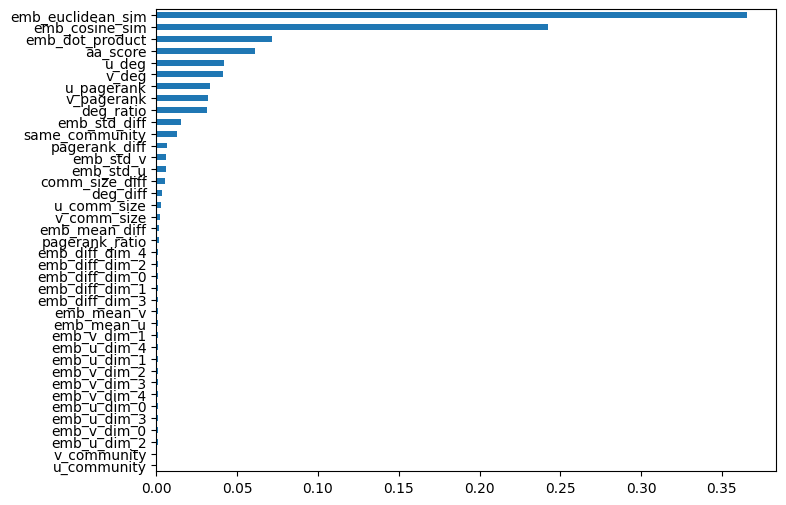

In [155]:
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(8,6))

In [156]:
import joblib
joblib.dump(best_model, "model.pkl")

['model.pkl']

In [157]:
# Carregar dataset de teste OTIMIZADO
edges = pd.read_csv('../data/datasetTeste_node2vec.csv')
edges = edges.drop(columns=['u', 'v'])  # Remover colunas de identificação
print(f"Dataset de teste OTIMIZADO: {edges.shape}")
print(f"Features: {list(edges.columns)}")
edges.head()

Dataset de teste OTIMIZADO: (500, 39)
Features: ['u_deg', 'v_deg', 'u_pagerank', 'v_pagerank', 'deg_diff', 'pagerank_diff', 'deg_ratio', 'pagerank_ratio', 'aa_score', 'u_community', 'v_community', 'same_community', 'u_comm_size', 'v_comm_size', 'comm_size_diff', 'emb_dot_product', 'emb_cosine_sim', 'emb_euclidean_sim', 'emb_mean_u', 'emb_mean_v', 'emb_std_u', 'emb_std_v', 'emb_mean_diff', 'emb_std_diff', 'emb_u_dim_0', 'emb_v_dim_0', 'emb_diff_dim_0', 'emb_u_dim_1', 'emb_v_dim_1', 'emb_diff_dim_1', 'emb_u_dim_2', 'emb_v_dim_2', 'emb_diff_dim_2', 'emb_u_dim_3', 'emb_v_dim_3', 'emb_diff_dim_3', 'emb_u_dim_4', 'emb_v_dim_4', 'emb_diff_dim_4']


,u_deg,v_deg,u_pagerank,v_pagerank,deg_diff,pagerank_diff,deg_ratio,pagerank_ratio,aa_score,u_community,...,emb_diff_dim_1,emb_u_dim_2,emb_v_dim_2,emb_diff_dim_2,emb_u_dim_3,emb_v_dim_3,emb_diff_dim_3,emb_u_dim_4,emb_v_dim_4,emb_diff_dim_4
0,0.006996,0.002186,0.000603,0.000259,0.004810,0.000344,0.312500,0.429478,0.0000,2,...,0.192673,0.478872,-0.091402,0.570274,0.149448,-0.222668,0.372115,-0.037644,0.205376,0.243019
1,0.002624,0.001968,0.000272,0.000203,0.000656,0.000069,0.749997,0.747034,0.3034,0,...,0.401468,-0.572563,-0.657659,0.085096,0.476411,-0.591430,1.067841,0.322233,0.171428,0.150805
2,0.008745,0.017272,0.000729,0.001886,0.008526,0.001156,0.506329,0.386730,0.2338,4,...,0.324805,-0.090238,-0.386584,0.296346,0.338730,-0.037695,0.376426,-0.625455,-0.044395,0.581060
3,0.001530,0.004373,0.000164,0.000461,0.002842,0.000298,0.349999,0.354491,0.4762,2,...,0.153970,-0.101095,0.199326,0.300421,-0.305940,-0.414344,0.108404,0.024661,-0.272960,0.297621
4,0.000000,0.000000,0.000038,0.000038,0.000000,0.000000,0.000000,0.999735,0.0000,411,...,0.016603,0.029617,-0.029250,0.058867,-0.005774,-0.015358,0.009584,-0.018123,-0.010319,0.007804


In [158]:
# Verificar compatibilidade entre datasets de treino e teste
print("=== VERIFICAÇÃO DE COMPATIBILIDADE ===")

# Verificar se as colunas são iguais
missing_in_test = set(X.columns) - set(edges.columns)
extra_in_test = set(edges.columns) - set(X.columns)

if missing_in_test:
    print(f"Colunas ausentes no teste: {missing_in_test}")
if extra_in_test:
    print(f"Colunas extras no teste: {extra_in_test}")
    
if not missing_in_test and not extra_in_test:
    print("Datasets são compatíveis!")
    print("Predição pode prosseguir!")
else:
    print("ATENÇÃO: Datasets NÃO são compatíveis!")
    print("Corrija os datasets antes de fazer predições!")



=== VERIFICAÇÃO DE COMPATIBILIDADE ===
Datasets são compatíveis!
Predição pode prosseguir!


In [159]:
# Fazer predições no conjunto de teste
try:
    print("Fazendo predições...")
    prediction = best_model.predict(edges)
    print(f"Predições realizadas com sucesso!")
    print(f"Total de predições: {len(prediction)}")
    print(f"Links preditos como 1: {sum(prediction)} ({sum(prediction)/len(prediction)*100:.2f}%)")
    print(f"Links preditos como 0: {len(prediction)-sum(prediction)} ({(len(prediction)-sum(prediction))/len(prediction)*100:.2f}%)")
except Exception as e:
    print(f"Erro na predição: {e}")
    print("Verifique se os datasets são compatíveis!")

Fazendo predições...
Predições realizadas com sucesso!
Total de predições: 500
Links preditos como 1: 92 (18.40%)
Links preditos como 0: 408 (81.60%)
Predições realizadas com sucesso!
Total de predições: 500
Links preditos como 1: 92 (18.40%)
Links preditos como 0: 408 (81.60%)


In [160]:
submission = pd.read_csv('../data/edgesToEvaluate.csv')
submission = submission.drop(columns=['venue1', 'venue2'])
submission['link'] = prediction
submission = submission.sort_values(by='linkID')

In [161]:
submission.head()

,linkID,link
337,0,0
319,1,0
15,2,1
107,3,0
250,4,0


In [162]:
submission.to_csv('submissionOtimizado.csv', index=False)
print("Submissão OTIMIZADA salva: submissionOtimizado.csv")
print("Dataset com apenas 15 features mais importantes!")

Submissão OTIMIZADA salva: submissionOtimizado.csv
Dataset com apenas 15 features mais importantes!
